## Cell 1 — Install Dependencies

In [1]:
import subprocess, sys
packages = ['einops', 'editdistance', 'tqdm', 'sympy']
subprocess.run([sys.executable, '-m', 'pip', 'install'] + packages + ['--quiet'], check=False)
import torch
print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DTYPE  = torch.bfloat16 if torch.cuda.is_available() else torch.float32
print(f'Device  : {DEVICE}  dtype={DTYPE}')


PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
Device  : cuda  dtype=torch.bfloat16


## Cell 2 — Imports

In [3]:
import os, re, math, random, pickle, json, copy, warnings
from collections import OrderedDict, Counter
from pathlib import Path
from dataclasses import dataclass, field
from typing import Optional, Dict, List, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import editdistance
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence
from torch.amp import GradScaler, autocast
from torch.optim.lr_scheduler import LambdaLR

try:
    import sympy as sp
    HAS_SYMPY = True
    print('SymPy: OK')
except ImportError:
    HAS_SYMPY = False
    print('SymPy: NOT available — physics symbolic checks disabled')

print('All imports OK.')


SymPy: OK
All imports OK.


## Cell 3 — Configuration


In [4]:

CFG = {
    'pad_idx'          : 0,
    'unk_idx'          : 1,
    'bos_idx'          : 2,
    'eos_idx'          : 3,
    'sep_idx'          : 4,

    'dim'              : 128,
    'num_heads'        : 4,
    'head_dim'         : 32,
    'ffn_dim'          : 512,
    'enc_a_layers'     : 2,
    'enc_b_layers'     : 2,
    'dec_layers'       : 3,
    'dropout'          : 0.1,
    'max_seq_len'      : 600,

    'use_enc_a'        : True,
    'use_enc_b'        : True,
    'use_phys_bias'    : True,
    'use_pointer'      : True,
    'use_moe'          : False,
    'moe_top_layers'   : 2,
    'moe_num_experts'  : 4,
    'moe_top_k'        : 2,

    'lambda_ce'        : 1.0,
    'lambda_dim'       : 0.1,
    'lambda_coupling'  : 0.1,
    'lambda_color'     : 0.1,
    'lambda_perm'      : 0.05,
    'lambda_sympy'     : 0.05,
    'use_loss_dim'     : True,
    'use_loss_coupling': True,
    'use_loss_color'   : True,
    'use_loss_perm'    : True,
    'use_loss_sympy'   : True,

    'use_grammar_mask' : True,
    'use_paren_check'  : True,
    'beam_size'        : 1,      #
    'beam_phys_rerank' : False,

    'lr'               : 3e-4,
    'end_lr'           : 1e-5,
    'warmup_frac'      : 0.10,
    'epochs'           : 100,
    'batch_size'       : 16,
    'grad_accum'       : 2,
    'grad_clip'        : 1.0,
    'weight_decay'     : 1e-2,
    'label_smoothing'  : 0.05,

    'ckpt_dir'         : '/content/checkpoints/pure_transformer',
    'eval_dir'         : '/content/results/pure_transformer',
}

PAD_IDX = CFG['pad_idx']
BOS_IDX = CFG['bos_idx']
EOS_IDX = CFG['eos_idx']
SEP_IDX = CFG['sep_idx']

LABELS = ['QED', 'QCD']
os.makedirs(CFG['ckpt_dir'], exist_ok=True)
os.makedirs(CFG['eval_dir'],  exist_ok=True)
print('Config loaded.')
print(f"  dim={CFG['dim']}  heads={CFG['num_heads']}  dec_layers={CFG['dec_layers']}")
print(f"  use_phys_bias={CFG['use_phys_bias']}  use_pointer={CFG['use_pointer']}  use_moe={CFG['use_moe']}")


Config loaded.
  dim=128  heads=4  dec_layers=3
  use_phys_bias=True  use_pointer=True  use_moe=False


## Cell 4 — Vocabulary & Tokenizer



In [5]:
class AmplitudeTokenizer:

    def __init__(self, index_pool_size=1000, special_symbols=None, to_replace=True):
        self.index_pool_size = index_pool_size
        self.to_replace = to_replace
        if special_symbols is None:
            self.special_symbols = ['<PAD>','<UNK>','<BOS>','<EOS>','<SEP>','<TERM0>','<TERM1>']
        else:
            self.special_symbols = special_symbols
        self.index_pool  = [f'INDEX_{i}'  for i in range(index_pool_size)]
        self.pindex_pool = [f'PINDEX_{i}' for i in range(index_pool_size)]
        self.pat_particle = re.compile(r'(?P<prefix>\b(?:\w+_)?)?(?P<target>[ijkl]_\d+\b)')
        self.pat_num123   = re.compile(r'\b(?![psijkl]_)(?!MOMENTUM_)(?!\w+_\w+_)\w+_\d+\b')

    @staticmethod
    def remove_whitespace(t): return re.sub(r'\s+', '', t)
    @staticmethod
    def split_expression(t): return re.split(r' ', t)

    def normalize_indices(self, text):
        if not self.to_replace: return text
        text = self.remove_whitespace(text)
        text = re.sub(r'p_(\d+)', r'MOMENTUM_\1', text)
        text = re.sub(r's_(\d+)', r'MOMENTUM_\1', text)
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        ms = list(OrderedDict.fromkeys(self.pat_num123.findall(text)))
        it = iter(self.index_pool); mp = {}
        for m in ms:
            try: mp[m] = next(it)
            except StopIteration: raise RuntimeError('INDEX pool exhausted')
        for o, n in sorted(mp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        ps = list(OrderedDict.fromkeys(
            m.group('target') for m in sorted(
                self.pat_particle.finditer(text), key=lambda m: m.start())))
        it2 = iter(self.pindex_pool); pp = {}
        for m in ps:
            try: pp[m] = next(it2)
            except StopIteration: raise RuntimeError('PINDEX pool exhausted')
        for o, n in sorted(pp.items(), key=lambda x: len(x[0]), reverse=True):
            text = text.replace(o, n)
        return text

    def tokenize_amplitude(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text)
        text = text.replace('(*)', ' CONJ ').replace('(theta_W)', '_theta_W')
        text = text.replace('\\\\', '\\').replace('\\', ' \\ ').replace('%', ' % ')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = text.replace('_PINDEX', '_ PINDEX').replace('_INDEX', '_ INDEX')
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]

    def tokenize_squared(self, t):
        text = self.normalize_indices(t) if self.to_replace else t
        text = self.remove_whitespace(text).replace('(theta_W)', '_theta_W')
        for s in ['/', '+', '-', '*', ',', '^', '}', '(', ')', '=', '[', ']']:
            text = text.replace(s, f' {s} ')
        text = re.sub(r'\bm_(\w+)\b', r' m_\1 ', text)
        text = re.sub(r'\bs_(\d{2,})\b', r' s_\1 ', text)
        text = text.replace('reg_prop', ' reg_prop ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in self.split_expression(text) if x]

    # Interaction/diagram tokenizer — same splitting, no index replacement needed
    def tokenize_interaction(self, t):
        text = self.remove_whitespace(t)
        for s in ['/', '+', '-', '*', ',', '^', '(', ')', '[', ']', '{', '}', ':', '>']:
            text = text.replace(s, f' {s} ')
        text = re.sub(r' {2,}', ' ', text).strip()
        return [x for x in text.split() if x]


class Vocabulary:
    def __init__(self, tokens, special_symbols,
                 pad_idx=0, unk_idx=1, bos_idx=2, eos_idx=3, sep_idx=4, term_idx=None):
        if term_idx is None: term_idx = [5, 6]
        tokens = [t for t in list(tokens) if t not in special_symbols]
        self.token_list    = special_symbols + tokens
        self.token_to_idx  = {t: i for i, t in enumerate(self.token_list)}
        self.idx_to_token  = {i: t for t, i in self.token_to_idx.items()}
        self.pad_idx = pad_idx; self.unk_idx = unk_idx
        self.bos_idx = bos_idx; self.eos_idx = eos_idx
        self.sep_idx = sep_idx; self.term_idx = term_idx
        self.special_indices = set(self.token_to_idx[s] for s in special_symbols)

    def encode(self, tokens):
        return [self.token_to_idx.get(t, self.unk_idx) for t in tokens]

    def decode(self, indices, include_special=True):
        if include_special:
            return [self.idx_to_token.get(i, '<UNK>') for i in indices]
        return [self.idx_to_token.get(i, '<UNK>') for i in indices
                if i not in self.special_indices or i == self.sep_idx]

    def __len__(self): return len(self.token_list)
    def __getitem__(self, x):
        if isinstance(x, int): return self.idx_to_token.get(x, '<UNK>')
        return self.token_to_idx.get(x, self.unk_idx)

print('Vocabulary & Tokenizer defined.')


Vocabulary & Tokenizer defined.


## Cell 5 — Raw Data Parser & Loader


In [6]:
# # ── Configure your data paths here ───────────────────────────────────────────
# DATA_FILES = {
#     'qed': [
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-0.txt',
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-1.txt',
#         '/content/drive/MyDrive/Datasets/QED-2-to-2-diag-TreeLevel-2.txt',
#     ],
#     'qcd': [
#         '/content/drive/MyDrive/Datasets/QCD-2-to-2-diag-TreeLevel-5.txt',
#         '/content/drive/MyDrive/Datasets/QCD-2-to-2-diag-TreeLevel-6.txt',
#     ],
# }
PKL_PATH = '/content/drive/MyDrive/Datasets/processed_data.pkl'

# ─────────────────────────────────────────────────────────────────────────────
def parse_raw_txt_file(filepath):

    records = []
    with open(filepath, 'r') as f:
        for line in f:
            line = line.strip()
            if not line: continue
            parts = line.split(' : ')
            if len(parts) < 3: continue
            interaction = parts[0].strip()
            mid         = ' : '.join(parts[1:-1])
            squared     = parts[-1].strip()
            amp_match   = re.search(r':\s*(-[\d/]|i\*|[\d/])', mid)
            if amp_match:
                diagram   = mid[:amp_match.start()].strip()
                amplitude = mid[amp_match.start():].strip().lstrip(': ').strip()
            else:
                diagram   = mid
                amplitude = mid
            records.append({
                'interaction': interaction,
                'diagram'    : diagram,
                'amplitude'  : amplitude,
                'squared'    : squared,
            })
    return records


def load_and_tokenize_raw(filepaths, tokenizer, is_qcd=False):
    all_records = []
    for fp in filepaths:
        if not os.path.exists(fp):
            print(f'  [SKIP] {fp} not found')
            continue
        recs = parse_raw_txt_file(fp)
        for r in recs:
            r['int_tokens'] = tokenizer.tokenize_interaction(r['interaction'])
            r['diag_tokens']= tokenizer.tokenize_interaction(r['diagram'])
            # Encoder A input = interaction + SEP + diagram
            r['enc_a_tokens'] = r['int_tokens'] + ['<SEP>'] + r['diag_tokens']
            r['amp_tokens']   = tokenizer.tokenize_amplitude(r['amplitude'])
            r['sq_tokens']    = tokenizer.tokenize_squared(r['squared'])
            r['is_qcd']       = is_qcd
        all_records.extend(recs)
        print(f'  Loaded {len(recs):4d} records from {os.path.basename(fp)}')
    return all_records


def build_vocabulary(records, min_freq=1):
    special = ['<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>']
    a_ctr = Counter(); b_ctr = Counter(); t_ctr = Counter()
    for r in records:
        a_ctr.update(r['enc_a_tokens'])
        b_ctr.update(r['amp_tokens'])
        t_ctr.update(r['sq_tokens'])
    enc_a_vocab = Vocabulary([t for t,c in a_ctr.items() if c>=min_freq], special)
    enc_b_vocab = Vocabulary([t for t,c in b_ctr.items() if c>=min_freq], special)
    tgt_vocab   = Vocabulary([t for t,c in t_ctr.items() if c>=min_freq], special)
    return enc_a_vocab, enc_b_vocab, tgt_vocab


def train_val_test_split(records, train_ratio=0.8, val_ratio=0.1, seed=42):
    rng  = random.Random(seed)
    data = records[:]
    rng.shuffle(data)
    n    = len(data)
    n_tr = int(n * train_ratio)
    n_va = int(n * val_ratio)
    return data[:n_tr], data[n_tr:n_tr+n_va], data[n_tr+n_va:]


tokenizer = AmplitudeTokenizer()
RAW_DATA  = {}

if os.path.exists(PKL_PATH):
    print(f'Loading from pickle: {PKL_PATH}')
    with open(PKL_PATH, 'rb') as f:
        PKL = pickle.load(f)
    for label in ['qed', 'qcd']:
        all_recs = PKL[label]['train'] + PKL[label]['val'] + PKL[label]['test']
        for r in all_recs:
            if 'enc_a_tokens' not in r:
                int_toks  = tokenizer.tokenize_interaction(r.get('interaction',''))
                diag_toks = tokenizer.tokenize_interaction(r.get('diagram',''))
                r['enc_a_tokens'] = int_toks + ['<SEP>'] + diag_toks
            if 'amp_tokens' not in r:
                r['amp_tokens'] = tokenizer.tokenize_amplitude(r.get('amplitude',''))
            if 'sq_tokens' not in r:
                r['sq_tokens']  = tokenizer.tokenize_squared(r.get('squared',''))
        enc_a_v, enc_b_v, tgt_v = build_vocabulary(all_recs)
        RAW_DATA[label.upper()] = {
            'train'      : PKL[label]['train'],
            'val'        : PKL[label]['val'],
            'test'       : PKL[label]['test'],
            'enc_a_vocab': enc_a_v,
            'enc_b_vocab': enc_b_v,
            'tgt_vocab'  : tgt_v,
        }
        tr,va,te = len(PKL[label]['train']),len(PKL[label]['val']),len(PKL[label]['test'])
        print(f'{label.upper()}: train={tr}  val={va}  test={te}  '
              f'enc_a_vocab={len(enc_a_v)}  enc_b_vocab={len(enc_b_v)}  tgt_vocab={len(tgt_v)}')
else:
    for label, paths in DATA_FILES.items():
        is_qcd  = (label == 'qcd')
        all_recs= load_and_tokenize_raw(paths, tokenizer, is_qcd=is_qcd)
        if not all_recs:
            print(f'  [WARN] No records for {label} — check DATA_FILES paths')
            continue
        train_r, val_r, test_r = train_val_test_split(all_recs)
        enc_a_v, enc_b_v, tgt_v = build_vocabulary(train_r)
        RAW_DATA[label.upper()] = {
            'train'      : train_r, 'val': val_r, 'test': test_r,
            'enc_a_vocab': enc_a_v, 'enc_b_vocab': enc_b_v, 'tgt_vocab': tgt_v,
        }
        print(f'{label.upper()}: train={len(train_r)}  val={len(val_r)}  test={len(test_r)}  '
              f'enc_a_vocab={len(enc_a_v)}  enc_b_vocab={len(enc_b_v)}  tgt_vocab={len(tgt_v)}')

print('Data loading done.')


Loading from pickle: /content/drive/MyDrive/Datasets/processed_data.pkl
QED: train=288  val=36  test=36  enc_a_vocab=1018  enc_b_vocab=97  tgt_vocab=43
QCD: train=187  val=23  test=24  enc_a_vocab=954  enc_b_vocab=179  tgt_vocab=67
Data loading done.


## Cell 6 — Physics Token Classifier


In [7]:


import re as _re

_MANDELSTAM = _re.compile(r'^s_\d{2,}$')
_MASS_FAM   = _re.compile(r'^m_(e|mu|tau|u|d|s|c|b|t|tt|W|Z|H)$')
_COUPLING   = {'e', 'g', 'g_s', 'g_w', 'alpha', 'alpha_s', 'alpha_w'}
_COLOR      = {'C_A', 'C_F', 'T_F', 'N_c', 'color', 'SU3', 'Tr', 'delta_col'}
_PROPAGATOR = {'reg_prop', 'prop', 'D'}
_GAMMA      = _re.compile(r'^(gamma|slash|\\gamma|Gamma).*')
_OPEN_P     = {'(', '[', '{'}
_CLOSE_P    = {')', ']', '}'}

def token_family(tok: str):
    if _MANDELSTAM.match(tok): return 'mandelstam'
    if _MASS_FAM.match(tok):   return 'mass'
    if tok in _COUPLING:       return 'coupling'
    if tok in _COLOR:          return 'color'
    if tok in _PROPAGATOR:     return 'propagator'
    if _GAMMA.match(tok):      return 'gamma'
    return None

def build_physics_bias_matrix(tokens: List[str], bias_val: float = 2.0) -> torch.Tensor:

    L = len(tokens)
    B = torch.zeros(L, L)
    families = [token_family(t) for t in tokens]

    for i in range(L):
        if families[i] is None: continue
        for j in range(L):
            if i != j and families[j] == families[i]:
                B[i, j] += bias_val

    # propagator neighbourhood
    for k, f in enumerate(families):
        if f == 'propagator':
            for d in range(1, 3):
                for nb in [k-d, k+d]:
                    if 0 <= nb < L:
                        B[k, nb] += bias_val * 0.5
                        B[nb, k] += bias_val * 0.5
    return B

print('Physics token classifier defined.')
print('  Families: mandelstam, mass, coupling, color, propagator, gamma')


Physics token classifier defined.
  Families: mandelstam, mass, coupling, color, propagator, gamma


## Cell 7 — Building Blocks (RMSNorm, RoPE, FFN, MoE)

In [8]:
class RMSNorm(nn.Module):
    def __init__(self, dim: int, eps: float = 1e-6):
        super().__init__()
        self.eps    = eps
        self.weight = nn.Parameter(torch.ones(dim))
    def forward(self, x):
        return x / (x.pow(2).mean(-1, keepdim=True) + self.eps).sqrt() * self.weight


class RoPEEmbedding(nn.Module):
    def __init__(self, head_dim: int, max_seq: int = 2048):
        super().__init__()
        assert head_dim % 2 == 0
        inv = 1.0 / (10000 ** (torch.arange(0, head_dim, 2).float() / head_dim))
        self.register_buffer('inv_freq', inv)
        self._build(max_seq)

    def _build(self, L, device=None, dtype=None):
        inv  = self.inv_freq
        pos  = torch.arange(L, device=inv.device, dtype=torch.float32)
        sincos = torch.einsum('i,j->ij', pos, inv)
        sin    = sincos.sin()
        cos    = sincos.cos()
        self.register_buffer('sin', sin, persistent=False)
        self.register_buffer('cos', cos, persistent=False)

    def _rotate_half(self, x):
        x1 = x[..., ::2]; x2 = x[..., 1::2]
        return torch.stack([-x2, x1], dim=-1).flatten(-2)

    def forward(self, x, offset: int = 0):
        L = x.shape[2]
        if L + offset > self.sin.shape[0]:
            self._build(L + offset + 64, device=x.device, dtype=x.dtype)
        sin = self.sin[offset:offset+L].to(x.dtype)
        cos = self.cos[offset:offset+L].to(x.dtype)
        sin2 = torch.stack([sin, sin], dim=-1).flatten(-2)
        cos2 = torch.stack([cos, cos], dim=-1).flatten(-2)
        return x * cos2 + self._rotate_half(x) * sin2


class FFN(nn.Module):
    def __init__(self, dim: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(dim, ffn_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(ffn_dim, dim),
            nn.Dropout(dropout),
        )
    def forward(self, x): return self.net(x)


class MoEFFN(nn.Module):

    def __init__(self, dim: int, ffn_dim: int, num_experts: int = 4,
                 top_k: int = 2, dropout: float = 0.1):
        super().__init__()
        self.num_experts = num_experts
        self.top_k       = top_k
        self.router      = nn.Linear(dim, num_experts, bias=False)
        self.experts     = nn.ModuleList([FFN(dim, ffn_dim, dropout) for _ in range(num_experts)])
        self.aux_loss    = torch.tensor(0.0)

    def forward(self, x):
        B, L, D = x.shape
        N       = B * L
        flat    = x.view(N, D)

        logits  = self.router(flat)
        probs   = torch.softmax(logits, dim=-1)
        topk_p, topk_idx = probs.topk(self.top_k, dim=-1)
        topk_p  = topk_p / topk_p.sum(dim=-1, keepdim=True)

        out = torch.zeros_like(flat)
        for k in range(self.top_k):
            idx   = topk_idx[:, k]
            gates = topk_p[:, k]
            for e in range(self.num_experts):
                mask = (idx == e)
                if mask.any():
                    out[mask] += gates[mask, None] * self.experts[e](flat[mask])

        E    = self.num_experts
        f_e  = torch.stack([(topk_idx == e).float().mean() for e in range(E)])
        p_e  = probs.mean(dim=0)
        self.aux_loss = (E * (f_e * p_e).sum()).detach().clone().requires_grad_(False)
        self.aux_loss_grad = E * (f_e * p_e).sum()

        return out.view(B, L, D)


print('Building blocks (RMSNorm, RoPE, FFN, MoEFFN) defined.')


Building blocks (RMSNorm, RoPE, FFN, MoEFFN) defined.


## Cell 8 — Physics-Biased Multi-Head Attention
Pre-norm self-attention and cross-attention with RoPE and optional additive physics bias.

In [9]:
class PhysicsBiasedMHA(nn.Module):

    def __init__(self, dim: int, num_heads: int, dropout: float = 0.1,
                 is_cross: bool = False):
        super().__init__()
        assert dim % num_heads == 0
        self.num_heads = num_heads
        self.head_dim  = dim // num_heads
        self.scale     = self.head_dim ** -0.5
        self.is_cross  = is_cross

        self.q_proj = nn.Linear(dim, dim, bias=False)
        self.k_proj = nn.Linear(dim, dim, bias=False)
        self.v_proj = nn.Linear(dim, dim, bias=False)
        self.o_proj = nn.Linear(dim, dim, bias=False)
        self.drop   = nn.Dropout(dropout)
        self.rope   = RoPEEmbedding(self.head_dim)

    def _split_heads(self, x):
        B, L, D = x.shape
        return x.view(B, L, self.num_heads, self.head_dim).transpose(1, 2)

    def forward(self, q_in, k_in, v_in,
                key_padding_mask=None,
                attn_mask=None,
                phys_bias=None,
                use_phys_bias: bool = True):
        B = q_in.shape[0]
        Q = self._split_heads(self.q_proj(q_in))
        K = self._split_heads(self.k_proj(k_in))
        V = self._split_heads(self.v_proj(v_in))

        Q = self.rope(Q)
        K = self.rope(K)

        attn = torch.matmul(Q, K.transpose(-2, -1)) * self.scale

        if use_phys_bias and phys_bias is not None:
            pb = phys_bias.to(attn.dtype).to(attn.device)
            if pb.dim() == 2:
                pb = pb.unsqueeze(0).unsqueeze(0)
            elif pb.dim() == 3:
                pb = pb.unsqueeze(1)
            attn = attn + pb

        if attn_mask is not None:
            attn = attn + attn_mask.to(attn.dtype).unsqueeze(0).unsqueeze(0)

        if key_padding_mask is not None:

            attn = attn.masked_fill(
                key_padding_mask.unsqueeze(1).unsqueeze(2), float('-inf'))

        w    = self.drop(torch.softmax(attn, dim=-1))
        out  = torch.matmul(w, V)
        out  = out.transpose(1, 2).contiguous().view(B, -1, self.num_heads * self.head_dim)
        return self.o_proj(out)


print('PhysicsBiasedMHA defined.')


PhysicsBiasedMHA defined.


## Cell 9 — Encoder Block & Encoder Stack

In [10]:
class EncoderBlock(nn.Module):
    def __init__(self, dim: int, num_heads: int, ffn_dim: int, dropout: float = 0.1):
        super().__init__()
        self.norm1 = RMSNorm(dim)
        self.norm2 = RMSNorm(dim)
        self.attn  = PhysicsBiasedMHA(dim, num_heads, dropout, is_cross=False)
        self.ffn   = FFN(dim, ffn_dim, dropout)

    def forward(self, x, key_padding_mask=None, phys_bias=None, use_phys_bias=True):
        # Self-attention (pre-norm)
        h    = self.norm1(x)
        x    = x + self.attn(h, h, h,
                              key_padding_mask=key_padding_mask,
                              phys_bias=phys_bias,
                              use_phys_bias=use_phys_bias)
        # FFN (pre-norm)
        x    = x + self.ffn(self.norm2(x))
        return x


class TransformerEncoder(nn.Module):

    def __init__(self, vocab_size: int, dim: int, num_heads: int,
                 ffn_dim: int, num_layers: int, dropout: float = 0.1,
                 pad_idx: int = 0, max_seq: int = 600):
        super().__init__()
        self.pad_idx = pad_idx
        self.embed   = nn.Embedding(vocab_size, dim, padding_idx=pad_idx)
        self.layers  = nn.ModuleList([
            EncoderBlock(dim, num_heads, ffn_dim, dropout)
            for _ in range(num_layers)
        ])
        self.norm    = RMSNorm(dim)
        nn.init.normal_(self.embed.weight, std=0.02)

    def forward(self, src, phys_bias=None, use_phys_bias=True):

        key_pad = (src == self.pad_idx)   # True = PAD = ignore
        x = self.embed(src)
        for layer in self.layers:
            x = layer(x, key_padding_mask=key_pad,
                      phys_bias=phys_bias, use_phys_bias=use_phys_bias)
        return self.norm(x), key_pad


print('EncoderBlock + TransformerEncoder defined.')


EncoderBlock + TransformerEncoder defined.


## Cell 10 — Decoder Block (Dual Cross-Attention) & Decoder Stack

In [11]:
class DecoderBlock(nn.Module):

    def __init__(self, dim: int, num_heads: int, ffn_dim: int, dropout: float = 0.1,
                 use_moe: bool = False, moe_num_experts: int = 4, moe_top_k: int = 2):
        super().__init__()
        self.norm_self   = RMSNorm(dim)
        self.norm_xattn  = RMSNorm(dim)
        self.norm_ffn    = RMSNorm(dim)
        self.self_attn   = PhysicsBiasedMHA(dim, num_heads, dropout, is_cross=False)
        self.cross_attn_a= PhysicsBiasedMHA(dim, num_heads, dropout, is_cross=True)
        self.cross_attn_b= PhysicsBiasedMHA(dim, num_heads, dropout, is_cross=True)
        self.gate_a = nn.Parameter(torch.ones(1))
        self.gate_b = nn.Parameter(torch.ones(1))
        if use_moe:
            self.ffn = MoEFFN(dim, ffn_dim, moe_num_experts, moe_top_k, dropout)
        else:
            self.ffn = FFN(dim, ffn_dim, dropout)

    def forward(self, x, mem_a, mem_b,
                mem_a_key_pad=None, mem_b_key_pad=None,
                self_attn_mask=None, phys_bias_self=None, phys_bias_cross=None,
                use_phys_bias=True, use_enc_a=True, use_enc_b=True):

        h  = self.norm_self(x)
        x  = x + self.self_attn(h, h, h,
                                  attn_mask=self_attn_mask,
                                  phys_bias=phys_bias_self,
                                  use_phys_bias=use_phys_bias)

        h  = self.norm_xattn(x)
        ca = torch.zeros_like(x)
        if use_enc_a and mem_a is not None:
            ca = ca + self.gate_a * self.cross_attn_a(
                h, mem_a, mem_a, key_padding_mask=mem_a_key_pad,
                phys_bias=phys_bias_cross, use_phys_bias=use_phys_bias)
        if use_enc_b and mem_b is not None:
            ca = ca + self.gate_b * self.cross_attn_b(
                h, mem_b, mem_b, key_padding_mask=mem_b_key_pad,
                phys_bias=phys_bias_cross, use_phys_bias=use_phys_bias)
        x  = x + ca

        # 3. FFN
        x  = x + self.ffn(self.norm_ffn(x))
        return x


class TransformerDecoder(nn.Module):

    def __init__(self, tgt_vocab_size: int, dim: int, num_heads: int,
                 ffn_dim: int, num_layers: int, dropout: float = 0.1,
                 pad_idx: int = 0, max_seq: int = 600,
                 use_moe: bool = False, moe_top_layers: int = 2,
                 moe_num_experts: int = 4, moe_top_k: int = 2):
        super().__init__()
        self.pad_idx   = pad_idx
        self.embed     = nn.Embedding(tgt_vocab_size, dim, padding_idx=pad_idx)
        self.norm      = RMSNorm(dim)
        moe_start      = num_layers - moe_top_layers

        self.layers    = nn.ModuleList([
            DecoderBlock(
                dim, num_heads, ffn_dim, dropout,
                use_moe=(use_moe and i >= moe_start),
                moe_num_experts=moe_num_experts,
                moe_top_k=moe_top_k,
            )
            for i in range(num_layers)
        ])
        nn.init.normal_(self.embed.weight, std=0.02)

    def _causal_mask(self, L, device):
        mask = torch.full((L, L), float('-inf'), device=device)
        mask = torch.triu(mask, diagonal=1)
        return mask

    def forward(self, tgt, mem_a, mem_b,
                mem_a_key_pad=None, mem_b_key_pad=None,
                phys_bias_self=None, phys_bias_cross=None,
                use_phys_bias=True, use_enc_a=True, use_enc_b=True):

        B, T = tgt.shape
        causal = self._causal_mask(T, tgt.device)
        x      = self.embed(tgt)
        moe_losses = []

        for layer in self.layers:
            x = layer(x, mem_a, mem_b,
                      mem_a_key_pad=mem_a_key_pad,
                      mem_b_key_pad=mem_b_key_pad,
                      self_attn_mask=causal,
                      phys_bias_self=phys_bias_self,
                      phys_bias_cross=phys_bias_cross,
                      use_phys_bias=use_phys_bias,
                      use_enc_a=use_enc_a,
                      use_enc_b=use_enc_b)
            if isinstance(layer.ffn, MoEFFN):
                  moe_losses.append(layer.ffn.aux_loss_grad)
        return self.norm(x), moe_losses


print('DecoderBlock + TransformerDecoder defined.')


DecoderBlock + TransformerDecoder defined.


## Cell 11 — Pointer-Generator Copy Mechanism

In [12]:
class PointerGeneratorHead(nn.Module):

    def __init__(self, dim: int, tgt_vocab_size: int, dropout: float = 0.1):
        super().__init__()
        self.tgt_vocab_size = tgt_vocab_size
        self.out_proj = nn.Linear(dim, tgt_vocab_size, bias=False)
        self.gen_gate = nn.Sequential(
            nn.Linear(dim * 2, dim),
            nn.Tanh(),
            nn.Linear(dim, 1),
            nn.Sigmoid(),
        )
        self.copy_q = nn.Linear(dim, dim, bias=False)
        self.copy_k = nn.Linear(dim, dim, bias=False)
        self.drop   = nn.Dropout(dropout)

    def forward(self, dec_hidden, mem_b, enc_b_ids, mem_b_key_pad=None):

        B, T, D = dec_hidden.shape
        V       = self.tgt_vocab_size
        Lb      = mem_b.shape[1]

        gen_logits = self.out_proj(dec_hidden)

        Q  = self.copy_q(dec_hidden)                    # [B, T, D]
        K  = self.copy_k(mem_b)                         # [B, Lb, D]
        sc = torch.bmm(Q, K.transpose(1, 2)) / (D ** 0.5)  # [B, T, Lb]
        if mem_b_key_pad is not None:
            sc = sc.masked_fill(mem_b_key_pad.unsqueeze(1), float('-inf'))
        copy_w = torch.softmax(sc, dim=-1)              # [B, T, Lb]


        safe_ids = enc_b_ids.clamp(0, V - 1)            # [B, Lb]
        ids_exp  = safe_ids.unsqueeze(1).expand(B, T, Lb)  # [B, T, Lb]

        copy_w_fp32   = copy_w.float()
        copy_dist_fp32= torch.zeros(B, T, V, device=dec_hidden.device, dtype=torch.float32)
        copy_dist_fp32.scatter_add_(2, ids_exp, copy_w_fp32)
        copy_dist = copy_dist_fp32.to(dec_hidden.dtype)


        ctx       = torch.bmm(copy_w, mem_b)             # [B, T, D]
        gate_in   = torch.cat([dec_hidden, ctx], dim=-1).float()  # float32
        gate_in   = gate_in.clamp(min=-1e4, max=1e4)
        gate      = self.gen_gate(gate_in).to(dec_hidden.dtype)   # [B, T, 1]


        gen_prob   = torch.softmax(gen_logits, dim=-1)
        final_prob = gate * gen_prob + (1.0 - gate) * copy_dist
        return torch.log(final_prob.clamp(min=1e-9))


print('PointerGeneratorHead defined (safe scatter + float32 gate).')


PointerGeneratorHead defined (safe scatter + float32 gate).


## Cell 12 — Full Model: PhysicsTransformerSYMBA

In [13]:
class PhysicsTransformerSYMBA(nn.Module):

    def __init__(self, cfg: dict):
        super().__init__()
        self.cfg = cfg
        dim        = cfg['dim']
        n_heads    = cfg['num_heads']
        ffn_dim    = cfg['ffn_dim']
        drop       = cfg['dropout']
        max_seq    = cfg['max_seq_len']
        enc_a_vs   = cfg['enc_a_vocab_size']
        enc_b_vs   = cfg['enc_b_vocab_size']
        tgt_vs     = cfg['tgt_vocab_size']

        self.enc_a = TransformerEncoder(
            enc_a_vs, dim, n_heads, ffn_dim,
            cfg['enc_a_layers'], drop, PAD_IDX, max_seq)

        self.enc_b = TransformerEncoder(
            enc_b_vs, dim, n_heads, ffn_dim,
            cfg['enc_b_layers'], drop, PAD_IDX, max_seq)

        self.decoder = TransformerDecoder(
            tgt_vs, dim, n_heads, ffn_dim,
            cfg['dec_layers'], drop, PAD_IDX, max_seq,
            use_moe=cfg.get('use_moe', False),
            moe_top_layers=cfg.get('moe_top_layers', 2),
            moe_num_experts=cfg.get('moe_num_experts', 4),
            moe_top_k=cfg.get('moe_top_k', 2),
        )

        if cfg.get('use_pointer', True):
            self.head = PointerGeneratorHead(dim, tgt_vs, drop)
        else:
            self.out_proj = nn.Linear(dim, tgt_vs, bias=False)
            self.head     = None
            # weight tying
            self.out_proj.weight = self.decoder.embed.weight

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, std=0.02)
                if m.bias is not None: nn.init.zeros_(m.bias)

    def _make_phys_bias(self, token_list):

        return build_physics_bias_matrix(token_list)

    def forward(self, enc_a_ids, enc_b_ids,
                tgt_ids,
                enc_a_tokens=None, enc_b_tokens=None,
                use_phys_bias=None, use_enc_a=None, use_enc_b=None, use_pointer=None):

        cfg = self.cfg
        if use_phys_bias is None: use_phys_bias = cfg.get('use_phys_bias', True)
        if use_enc_a     is None: use_enc_a     = cfg.get('use_enc_a',     True)
        if use_enc_b     is None: use_enc_b     = cfg.get('use_enc_b',     True)
        if use_pointer   is None: use_pointer   = cfg.get('use_pointer',   True)

        mem_a, pad_a = self.enc_a(enc_a_ids, use_phys_bias=use_phys_bias) if use_enc_a else (None, None)
        mem_b, pad_b = self.enc_b(enc_b_ids, use_phys_bias=use_phys_bias)

        dec_h, moe_losses = self.decoder(
            tgt_ids, mem_a, mem_b,
            mem_a_key_pad=pad_a, mem_b_key_pad=pad_b,
            use_phys_bias=use_phys_bias,
            use_enc_a=use_enc_a, use_enc_b=use_enc_b,
        )
        # aggregate MoE aux loss
        moe_aux = sum(moe_losses) / len(moe_losses) if moe_losses else torch.tensor(0.0, device=dec_h.device)

        if use_pointer and self.head is not None:
            log_probs = self.head(dec_h, mem_b, enc_b_ids, mem_b_key_pad=pad_b)
        else:
            log_probs = F.log_softmax(self.out_proj(dec_h), dim=-1)

        return log_probs, moe_aux

    def count_params(self):
        return sum(p.numel() for p in self.parameters() if p.requires_grad)


print('PhysicsTransformerSYMBA defined.')


PhysicsTransformerSYMBA defined.


## Cell 13 — Dataset & DataLoader


In [14]:
def get_max_lens(records, pct=97, cap=512):
    a_lens = [len(r.get('enc_a_tokens', [])) for r in records]
    b_lens = [len(r.get('amp_tokens',   [])) for r in records]
    t_lens = [len(r.get('sq_tokens',    [])) for r in records]
    a_max  = min(int(np.percentile(a_lens, pct)) + 4, cap)
    b_max  = min(int(np.percentile(b_lens, pct)) + 4, cap)
    t_max  = min(int(np.percentile(t_lens, pct)) + 4, cap)
    return a_max, b_max, t_max


def encode_records(records, enc_a_vocab, enc_b_vocab, tgt_vocab,
                   a_max, b_max, t_max):
    rows = []
    for r in records:
        a_toks = list(r.get('enc_a_tokens', []))
        b_toks = list(r.get('amp_tokens',   []))
        t_toks = list(r.get('sq_tokens',    []))
        a_ids = [BOS_IDX] + enc_a_vocab.encode(a_toks)[:a_max-2] + [EOS_IDX]
        b_ids = [BOS_IDX] + enc_b_vocab.encode(b_toks)[:b_max-2] + [EOS_IDX]
        t_ids = [BOS_IDX] + tgt_vocab.encode(t_toks)[:t_max-2]   + [EOS_IDX]
        rows.append({
            'enc_a_ids'   : a_ids,
            'enc_b_ids'   : b_ids,
            'tgt_ids'     : t_ids,
            'enc_a_tokens': a_toks,
            'enc_b_tokens': b_toks,
            'sq_tokens'   : t_toks,
            'squared'     : r.get('squared', ''),
            'is_qcd'      : bool(r.get('is_qcd', False)),
            'n_vertices'  : int(r.get('n_vertices', 2)),   # always int
        })
    return rows


class PhysicsDataset(Dataset):
    def __init__(self, rows, a_max, b_max, t_max):
        self.rows  = rows
        self.a_max = a_max
        self.b_max = b_max
        self.t_max = t_max

    def __len__(self): return len(self.rows)

    def __getitem__(self, i):
        r = self.rows[i]
        return {
            'enc_a_ids'   : torch.tensor(r['enc_a_ids'][:self.a_max],   dtype=torch.long),
            'enc_b_ids'   : torch.tensor(r['enc_b_ids'][:self.b_max],   dtype=torch.long),
            'tgt_ids'     : torch.tensor(r['tgt_ids'][:self.t_max],     dtype=torch.long),
            'enc_a_tokens': r['enc_a_tokens'],
            'enc_b_tokens': r['enc_b_tokens'],
            'sq_tokens'   : r['sq_tokens'],
            'squared'     : r['squared'],
            'is_qcd'      : r['is_qcd'],
            'n_vertices'  : r['n_vertices'],
        }


def collate_fn(batch):
    enc_a = pad_sequence([b['enc_a_ids'] for b in batch],
                         padding_value=PAD_IDX, batch_first=True)
    enc_b = pad_sequence([b['enc_b_ids'] for b in batch],
                         padding_value=PAD_IDX, batch_first=True)
    tgt   = pad_sequence([b['tgt_ids']   for b in batch],
                         padding_value=PAD_IDX, batch_first=True)
    meta  = {
        'enc_a_tokens': [b['enc_a_tokens'] for b in batch],
        'enc_b_tokens': [b['enc_b_tokens'] for b in batch],
        'sq_tokens'   : [b['sq_tokens']    for b in batch],
        'squared'     : [b['squared']      for b in batch],
        'is_qcd'      : [b['is_qcd']       for b in batch],   # list[bool]
        'n_vertices'  : [b['n_vertices']   for b in batch],   # list[int]
    }
    return enc_a, enc_b, tgt, meta


DATASETS = {}
for label in LABELS:
    if label not in RAW_DATA:
        print(f'  [SKIP] {label} not in RAW_DATA')
        continue
    rd      = RAW_DATA[label]
    a_max, b_max, t_max = get_max_lens(rd['train'])
    tr_rows = encode_records(rd['train'], rd['enc_a_vocab'], rd['enc_b_vocab'], rd['tgt_vocab'], a_max, b_max, t_max)
    va_rows = encode_records(rd['val'],   rd['enc_a_vocab'], rd['enc_b_vocab'], rd['tgt_vocab'], a_max, b_max, t_max)
    te_rows = encode_records(rd['test'],  rd['enc_a_vocab'], rd['enc_b_vocab'], rd['tgt_vocab'], a_max, b_max, t_max)
    DATASETS[label] = {
        'train'      : PhysicsDataset(tr_rows, a_max, b_max, t_max),
        'val'        : PhysicsDataset(va_rows, a_max, b_max, t_max),
        'test'       : PhysicsDataset(te_rows, a_max, b_max, t_max),
        'enc_a_vocab': rd['enc_a_vocab'],
        'enc_b_vocab': rd['enc_b_vocab'],
        'tgt_vocab'  : rd['tgt_vocab'],
        'a_max': a_max, 'b_max': b_max, 't_max': t_max,
    }
    print(f'{label}: train={len(tr_rows):5d}  val={len(va_rows):4d}  test={len(te_rows):4d}  '
          f'a_max={a_max}  b_max={b_max}  t_max={t_max}  '
          f'enc_a_vocab={len(rd["enc_a_vocab"])}  enc_b_vocab={len(rd["enc_b_vocab"])}  tgt_vocab={len(rd["tgt_vocab"])}')

print('Datasets built.')


QED: train=  288  val=  36  test=  36  a_max=65  b_max=183  t_max=128  enc_a_vocab=1018  enc_b_vocab=97  tgt_vocab=43
QCD: train=  187  val=  23  test=  24  a_max=85  b_max=512  t_max=512  enc_a_vocab=954  enc_b_vocab=179  tgt_vocab=67
Datasets built.


## Cell 14 — Physics Loss Functions


In [15]:
# ─── QCD Color factor lookup ───────────────────────────────────────────────────
QCD_COLOR_FACTORS = {
    (2, False): 4.0/9,
    (1, True):  1.0/6,
    (0, True):  9.0,
    (2, True):  16.0/27,
}


def check_coupling_power(pred_toks, n_vertices, is_qcd, tgt_vocab):
    coupling_toks = {'e', 'g', 'g_s', 'g_w'}
    cnt  = sum(1 for t in pred_toks if t in coupling_toks)
    exp  = 2 * n_vertices
    return cnt, exp, (cnt == exp)


def check_color_factor(pred_toks, n_quark_lines, has_gluon, tgt_vocab):
    key = (n_quark_lines, has_gluon)
    if key not in QCD_COLOR_FACTORS: return None, None, False
    exp_cf = QCD_COLOR_FACTORS[key]
    # look for numeric token matching expected CF
    frac_re = re.compile(r'^[\d]+(?:/[\d]+)?$')
    found = False
    for t in pred_toks:
        if frac_re.match(t):
            try:
                v = eval(t)
                if abs(v - exp_cf) < 0.01:
                    found = True; break
            except: pass
    return None, exp_cf, found


def sympy_validate(token_str, is_qcd):

    if not HAS_SYMPY: return False
    try:
        # re-join tokens into expression string
        expr_str = token_str.replace(' ^ ', '**').replace(' * ', '*').replace(' / ', '/')
        expr_str = expr_str.replace('s_', 's').replace('m_', 'm')
        expr = sp.sympify(expr_str, evaluate=False)
        return expr is not None
    except:
        return False



def coupling_loss_batch(log_probs, tgt_ids, tgt_vocab, n_vertices_list, is_qcd_list):

    coupling_ids = set()
    for tok in ['e', 'g', 'g_s', 'g_w']:
        idx = tgt_vocab[tok]
        if idx != tgt_vocab.unk_idx:
            coupling_ids.add(idx)
    if not coupling_ids:
        return torch.tensor(0.0, device=log_probs.device)

    B, T, V = log_probs.shape
    # Expected probability mass on coupling tokens per sequence
    coup_mask = torch.zeros(V, device=log_probs.device)
    for idx in coupling_ids: coup_mask[idx] = 1.0

    probs      = log_probs.exp()                          # [B, T, V]
    coup_prob  = (probs * coup_mask).sum(-1)              # [B, T]
    # non-pad positions
    non_pad    = (tgt_ids != PAD_IDX).float()             # [B, T]
    exp_count  = torch.tensor([2.0 * n for n in n_vertices_list],
                               device=log_probs.device)   # [B]
    pred_count = (coup_prob * non_pad).sum(-1)            # [B]
    loss = F.mse_loss(pred_count, exp_count.float())
    return loss


# ─── Mass-dimension consistency loss ─────────────────────────────────────────
def dim_loss_batch(log_probs, tgt_vocab):

    slash_id = tgt_vocab['/']
    if slash_id == tgt_vocab.unk_idx:
        return torch.tensor(0.0, device=log_probs.device)
    probs = log_probs.exp()
    slash_probs = probs[:, :, slash_id]

    loss = slash_probs.var(dim=-1).mean()
    return loss


# Permutation / symmetry consistency
def perm_loss_batch(log_probs, tgt_ids, tgt_vocab):


    probs   = log_probs.exp()
    entropy = -(probs * (probs + 1e-9).log()).sum(-1).mean()
    # very mild penalty: encourage sharpness
    return entropy * 0.001


print('Physics loss functions defined.')
print('  Losses: coupling, dim, color (eval-only), perm, sympy (eval-only)')


Physics loss functions defined.
  Losses: coupling, dim, color (eval-only), perm, sympy (eval-only)


## Cell 15 — SymPy Validation Layer (Evaluation-Time)

In [29]:
if HAS_SYMPY:
    _s12,_s13,_s14,_s23,_s24,_s34 = sp.symbols(
        's_12 s_13 s_14 s_23 s_24 s_34', real=True)
    _m_e,_m_mu,_m_tau = sp.symbols('m_e m_mu m_tau', positive=True)
    _m_u,_m_d,_m_s    = sp.symbols('m_u m_d m_s',   positive=True)
    _m_c,_m_b,_m_t    = sp.symbols('m_c m_b m_t',   positive=True)
    _m_tt              = sp.symbols('m_tt',            positive=True)
    _e,  _g            = sp.symbols('e g',             positive=True)
    _reg_prop          = sp.symbols('reg_prop',         positive=True)

    MANDELSTAM_VARS = {_s12,_s13,_s14,_s23,_s24,_s34}
    MASS_VARS       = {_m_e,_m_mu,_m_tau,_m_u,_m_d,_m_s,_m_c,_m_b,_m_t,_m_tt}
    COUPLING_VARS   = {_e, _g}
    ALLOWED_SYMBOLS = MANDELSTAM_VARS | MASS_VARS | COUPLING_VARS | {_reg_prop}

    SYMPY_LOCALS = {str(s): s for s in ALLOWED_SYMBOLS}

    for _i in range(20):
        _sym = sp.Symbol(f'INDEX_{_i}', positive=True)
        SYMPY_LOCALS[f'INDEX_{_i}'] = _sym
        _sym = sp.Symbol(f'PINDEX_{_i}', positive=True)
        SYMPY_LOCALS[f'PINDEX_{_i}'] = _sym
    # Common physics tokens that appear in expressions
    for _name in ['reg_prop', 'Nc', 'CF', 'CA', 'TF', 'pi', 'I']:
        SYMPY_LOCALS[_name] = sp.Symbol(_name, positive=True)

    def _tokens_to_expr_string(pred_tokens):

        skip = {'<PAD>', '<UNK>', '<BOS>', '<EOS>', '<SEP>', '<TERM0>', '<TERM1>', 'CONJ'}
        out  = []
        for tok in pred_tokens:
            if tok in skip:
                continue
            if tok == '^':
                out.append('**')
            else:
                out.append(tok)
        return ' '.join(out)

    def sympy_full_validate(pred_tokens):

        result = {'sympy_valid': False, 'dim_ok': False, 'coupling_ok_sympy': False}
        if not pred_tokens:
            return result

        expr_str = _tokens_to_expr_string(pred_tokens)
        if not expr_str.strip():
            return result

        try:
            expr = sp.sympify(expr_str, locals=SYMPY_LOCALS, evaluate=False)

            if not isinstance(expr, sp.Basic):
                return result

            result['sympy_valid'] = True


            free = expr.free_symbols
            unexpected = {
                s for s in free
                if str(s) not in SYMPY_LOCALS
            }
            result['dim_ok'] = (len(unexpected) == 0)

            coup_present = any(str(s) in ('e', 'g') for s in free)
            result['coupling_ok_sympy'] = coup_present

        except Exception:
            pass

        return result

else:
    def _tokens_to_expr_string(pred_tokens):
        return ' '.join(pred_tokens)

    def sympy_full_validate(pred_tokens):
        return {'sympy_valid': False, 'dim_ok': False, 'coupling_ok_sympy': False}

print('SymPy validation layer ready.')
print(f'  SYMPY_LOCALS keys ({len(SYMPY_LOCALS)}): {list(SYMPY_LOCALS.keys())[:10]} ...')
print(f'  HAS_SYMPY = {HAS_SYMPY}')


SymPy validation layer ready.
  SYMPY_LOCALS keys (65): ['m_u', 'm_e', 'm_d', 'm_mu', 's_23', 's_34', 'reg_prop', 'm_s', 'e', 's_12'] ...
  HAS_SYMPY = True


## Cell 16 — Model Builder & Parameter Count

In [17]:
def build_model(label: str, overrides: dict = None) -> 'PhysicsTransformerSYMBA':

    ds  = DATASETS[label]
    cfg = copy.deepcopy(CFG)
    cfg['enc_a_vocab_size'] = len(ds['enc_a_vocab'])
    cfg['enc_b_vocab_size'] = len(ds['enc_b_vocab'])
    cfg['tgt_vocab_size']   = len(ds['tgt_vocab'])
    if overrides:
        cfg.update(overrides)
    model = PhysicsTransformerSYMBA(cfg).to(DEVICE)
    return model, cfg


print('Model parameter counts (full CFG):')
for label in LABELS:
    if label not in DATASETS: continue
    m, _ = build_model(label)
    np_  = m.count_params()
    print(f'  {label}: {np_/1e6:.2f}M parameters')
    del m


Model parameter counts (full CFG):
  QED: 2.00M parameters
  QCD: 2.00M parameters


## Cell 17 — Training Loop (Mixed Precision, Physics Losses, MoE Aux Loss)

In [18]:
def smooth_nll_loss(log_probs_flat, targets_flat, ignore_index, smoothing):

    V    = log_probs_flat.size(-1)
    mask = (targets_flat != ignore_index)

    if not mask.any():
        return log_probs_flat.sum() * 0.0

    lp   = log_probs_flat[mask]                    # [M, V]
    tgt  = targets_flat[mask]                      # [M]

    # Hard-target NLL
    nll  = F.nll_loss(lp, tgt, reduction='mean')

    if smoothing == 0.0:
        return nll

    smooth_loss = -lp.mean()                       # mean over vocab & positions

    return (1.0 - smoothing) * nll + smoothing * smooth_loss


def train_model(label: str, run_name: str, overrides: dict = None,
                n_epochs: int = None, lr: float = None):

    model, cfg = build_model(label, overrides)
    ds         = DATASETS[label]
    ckpt_dir   = os.path.join(cfg['ckpt_dir'], run_name)
    os.makedirs(ckpt_dir, exist_ok=True)

    EPOCHS       = n_epochs or cfg['epochs']
    LR           = lr or cfg['lr']
    END_LR       = cfg['end_lr']
    WARMUP       = cfg['warmup_frac']
    BATCH        = cfg['batch_size']
    GRAD_ACCUM   = cfg['grad_accum']
    CLIP         = cfg['grad_clip']
    SMOOTHING    = cfg.get('label_smoothing', 0.05)

    train_loader = DataLoader(ds['train'], batch_size=BATCH, shuffle=True,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)
    val_loader   = DataLoader(ds['val'],   batch_size=BATCH, shuffle=False,
                              collate_fn=collate_fn, num_workers=0, pin_memory=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=cfg['weight_decay'])

    total_steps  = EPOCHS * math.ceil(len(ds['train']) / (BATCH * GRAD_ACCUM))
    warmup_steps = int(total_steps * WARMUP)

    def lr_lambda(step):
        if step < warmup_steps:
            return step / max(1, warmup_steps)
        prog = (step - warmup_steps) / max(1, total_steps - warmup_steps)
        return max(END_LR/LR, 0.5*(1 + math.cos(math.pi * prog)))

    scheduler = LambdaLR(optimizer, lr_lambda)
    scaler    = GradScaler(enabled=torch.cuda.is_available())
    tgt_vocab = ds['tgt_vocab']

    history = {'tr_loss':[], 'val_loss':[], 'tr_tok_acc':[], 'val_tok_acc':[]}
    best_val_loss = float('inf')
    global_step   = 0

    print(f'\nTraining {label} — {run_name}  |  {model.count_params()/1e6:.2f}M params  '
          f'|  {EPOCHS} epochs  |  effective batch={BATCH*GRAD_ACCUM}  '
          f'|  label_smoothing={SMOOTHING}')

    for epoch in range(1, EPOCHS + 1):
        model.train()
        tr_loss_sum = 0.0; tr_correct = 0; tr_total = 0
        optimizer.zero_grad()

        for step, (enc_a, enc_b, tgt, meta) in enumerate(train_loader):
            enc_a = enc_a.to(DEVICE)
            enc_b = enc_b.to(DEVICE)
            tgt   = tgt.to(DEVICE)

            dec_in  = tgt[:, :-1]
            dec_tgt = tgt[:, 1:].contiguous()

            with autocast(device_type=str(DEVICE).split(':')[0], dtype=DTYPE):
                log_probs, moe_aux = model(enc_a, enc_b, dec_in)

                B, T, V  = log_probs.shape
                lp_flat  = log_probs.view(B * T, V)
                tg_flat  = dec_tgt.view(-1)

                loss_ce  = smooth_nll_loss(lp_flat, tg_flat, PAD_IDX, SMOOTHING)

                loss_aux = torch.tensor(0.0, device=DEVICE, dtype=log_probs.dtype)

                if cfg.get('use_loss_coupling') and cfg.get('lambda_coupling', 0) > 0:
                    lc = coupling_loss_batch(log_probs, dec_tgt, tgt_vocab,
                                             meta['n_vertices'], meta['is_qcd'])
                    loss_aux = loss_aux + cfg['lambda_coupling'] * lc

                if cfg.get('use_loss_dim') and cfg.get('lambda_dim', 0) > 0:
                    ld = dim_loss_batch(log_probs, tgt_vocab)
                    loss_aux = loss_aux + cfg['lambda_dim'] * ld

                if cfg.get('use_loss_perm') and cfg.get('lambda_perm', 0) > 0:
                    lp_aux = perm_loss_batch(log_probs, dec_tgt, tgt_vocab)
                    loss_aux = loss_aux + cfg['lambda_perm'] * lp_aux

                loss_moe = (0.01 * moe_aux.to(log_probs.dtype)
                            if cfg.get('use_moe') else
                            torch.tensor(0.0, device=DEVICE, dtype=log_probs.dtype))

                loss = (cfg['lambda_ce'] * loss_ce + loss_aux + loss_moe) / GRAD_ACCUM

            scaler.scale(loss).backward()

            if (step + 1) % GRAD_ACCUM == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), CLIP)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
                scheduler.step()
                global_step += 1

            with torch.no_grad():
                preds        = log_probs.argmax(-1)
                mask         = (dec_tgt != PAD_IDX)
                tr_correct  += (preds == dec_tgt)[mask].sum().item()
                tr_total    += mask.sum().item()
                tr_loss_sum += loss_ce.item()

        tr_loss_avg = tr_loss_sum / len(train_loader)
        tr_tok_acc  = tr_correct / max(tr_total, 1)

        model.eval()
        val_loss_sum = 0.0; val_correct = 0; val_total = 0
        with torch.no_grad():
            for enc_a, enc_b, tgt, meta in val_loader:
                enc_a = enc_a.to(DEVICE)
                enc_b = enc_b.to(DEVICE)
                tgt   = tgt.to(DEVICE)
                dec_in  = tgt[:, :-1]
                dec_tgt = tgt[:, 1:].contiguous()
                with autocast(device_type=str(DEVICE).split(':')[0], dtype=DTYPE):
                    log_probs, _ = model(enc_a, enc_b, dec_in)
                B, T, V = log_probs.shape
                # use smoothing=0 for val loss (plain NLL = true perplexity)
                val_loss_sum += smooth_nll_loss(
                    log_probs.view(B*T, V), dec_tgt.view(-1), PAD_IDX, smoothing=0.0).item()
                preds     = log_probs.argmax(-1)
                mask      = (dec_tgt != PAD_IDX)
                val_correct += (preds == dec_tgt)[mask].sum().item()
                val_total   += mask.sum().item()

        val_loss_avg = val_loss_sum / len(val_loader)
        val_tok_acc  = val_correct / max(val_total, 1)

        history['tr_loss'].append(tr_loss_avg)
        history['val_loss'].append(val_loss_avg)
        history['tr_tok_acc'].append(tr_tok_acc)
        history['val_tok_acc'].append(val_tok_acc)

        print(f'  Epoch {epoch:3d}/{EPOCHS}  '
              f'tr_loss={tr_loss_avg:.4f}  val_loss={val_loss_avg:.4f}  '
              f'tr_tok={tr_tok_acc*100:.1f}%  val_tok={val_tok_acc*100:.1f}%  '
              f'lr={scheduler.get_last_lr()[0]:.2e}')

        if val_loss_avg < best_val_loss:
            best_val_loss = val_loss_avg
            ckpt = {'model': model.state_dict(), 'cfg': cfg,
                    'epoch': epoch, 'val_loss': val_loss_avg}
            torch.save(ckpt, os.path.join(ckpt_dir, f'{label}_best.pth'))
            print(f'    ✓ Saved best checkpoint (val_loss={val_loss_avg:.4f})')

    return history, os.path.join(ckpt_dir, f'{label}_best.pth')


print('Training loop defined (label-smoothed NLL — NLLLoss-compatible).')


Training loop defined (label-smoothed NLL — NLLLoss-compatible).


## Cell 18 — Constrained Decoding
Grammar mask, parenthesis balance, optional beam search with physics re-ranking.

In [19]:

def make_grammar_mask(tgt_vocab):

    V = len(tgt_vocab)
    mask = torch.ones(V, V, dtype=torch.bool)
    ops  = {tgt_vocab[t] for t in ['+', '-', '*', '/', '^', '='] if tgt_vocab[t] != tgt_vocab.unk_idx}
    opens  = {tgt_vocab[t] for t in ['(', '['] if tgt_vocab[t] != tgt_vocab.unk_idx}
    closes = {tgt_vocab[t] for t in [')', ']'] if tgt_vocab[t] != tgt_vocab.unk_idx}
    for op in ops:
        for op2 in ops:
            mask[op, op2] = False
        for cl in closes:
            mask[op, cl]  = False
    bos_id = tgt_vocab.bos_idx
    for op in ops:    mask[bos_id, op] = False
    for cl in closes: mask[bos_id, cl] = False
    return mask  # [V, V]


@torch.no_grad()
def greedy_decode(model, enc_a_ids, enc_b_ids, tgt_vocab,
                  max_len=256, use_grammar_mask=True, use_paren_check=True,
                  grammar_mask=None, use_phys_bias=True, use_enc_a=True,
                  use_enc_b=True, use_pointer=True):

    model.eval()
    device      = enc_a_ids.device
    generated   = [BOS_IDX]
    paren_depth = 0
    EOS         = EOS_IDX
    V           = len(tgt_vocab)

    for _ in range(max_len):
        dec_in  = torch.tensor([generated], dtype=torch.long, device=device)
        lp, _   = model(enc_a_ids, enc_b_ids, dec_in,
                        use_phys_bias=use_phys_bias,
                        use_enc_a=use_enc_a, use_enc_b=use_enc_b,
                        use_pointer=use_pointer)
        logits = lp[0, -1, :]  # [V]

        if use_grammar_mask and grammar_mask is not None:
            prev_tok = generated[-1]
            if prev_tok < V:
                invalid = ~grammar_mask[prev_tok].to(device)
                logits  = logits.masked_fill(invalid, float('-inf'))

        if use_paren_check:
            open_id  = tgt_vocab['(']
            close_id = tgt_vocab[')']
            if open_id != tgt_vocab.unk_idx and close_id != tgt_vocab.unk_idx:
                if paren_depth == 0:
                    logits[close_id] = float('-inf')

        next_tok = logits.argmax().item()

        tok_str = tgt_vocab[next_tok]
        if tok_str in ('(', '['):    paren_depth += 1
        elif tok_str in (')', ']'):  paren_depth  = max(0, paren_depth - 1)

        if next_tok == EOS: break
        generated.append(next_tok)

    return generated[1:]  # strip BOS


@torch.no_grad()
def beam_decode(model, enc_a_ids, enc_b_ids, tgt_vocab,
                beam_size=4, max_len=256, physics_rerank=False,
                use_phys_bias=True, use_enc_a=True, use_enc_b=True,
                use_pointer=True):

    model.eval()
    device  = enc_a_ids.device
    EOS     = EOS_IDX
    V       = len(tgt_vocab)

    # beams: list of (log_prob, token_ids)
    beams = [(0.0, [BOS_IDX])]

    for step in range(max_len):
        all_candidates = []
        for score, seq in beams:
            if seq[-1] == EOS:
                all_candidates.append((score, seq))
                continue
            dec_in = torch.tensor([seq], dtype=torch.long, device=device)
            lp, _  = model(enc_a_ids, enc_b_ids, dec_in,
                           use_phys_bias=use_phys_bias,
                           use_enc_a=use_enc_a, use_enc_b=use_enc_b,
                           use_pointer=use_pointer)
            logits = lp[0, -1, :]  # [V]
            topk   = logits.topk(beam_size)
            for lv, idx in zip(topk.values.tolist(), topk.indices.tolist()):
                all_candidates.append((score + lv, seq + [idx]))

        # keep top beam_size
        all_candidates.sort(key=lambda x: x[0], reverse=True)
        beams = all_candidates[:beam_size]

        # check if all beams ended
        if all(seq[-1] == EOS for _, seq in beams): break

    if physics_rerank:
        def physics_score(seq):
            toks = [tgt_vocab[i] for i in seq[1:] if i != EOS]
            res  = sympy_full_validate(toks)
            return float(res.get('sympy_valid', False)) + float(res.get('dim_ok', False))
        beams.sort(key=lambda x: physics_score(x[1]), reverse=True)

    best = beams[0][1]
    # strip BOS / EOS
    return [t for t in best[1:] if t != EOS]


print('Constrained decoding (greedy + beam) defined.')


Constrained decoding (greedy + beam) defined.


## Cell 19 — Evaluation with Full Physics Metrics

In [20]:
def evaluate(label: str, run_name: str, ablation_flags: dict = None, batch_size: int = 8):

    ds        = DATASETS[label]
    tgt_vocab = ds['tgt_vocab']
    ckpt_path = os.path.join(CFG['ckpt_dir'], run_name, f'{label}_best.pth')
    if not os.path.exists(ckpt_path):
        print(f'  [MISSING] {ckpt_path}')
        return None

    # Load checkpoint
    pkg = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    cfg = pkg['cfg']
    if ablation_flags: cfg.update(ablation_flags)

    model, _ = build_model(label, cfg)
    model.load_state_dict(pkg['model'], strict=False)
    model.eval()

    # Grammar mask
    grammar_mask = make_grammar_mask(tgt_vocab) if cfg.get('use_grammar_mask') else None

    loader = DataLoader(ds['test'], batch_size=batch_size, shuffle=False,
                        collate_fn=collate_fn)

    ce_fn_eval = lambda lp, tg: smooth_nll_loss(lp, tg, PAD_IDX, smoothing=0.0)
    metrics = {'ce_loss':0,'tok_correct':0,'tok_total':0,
               'seq_correct':0,'seq_total':0,'edit_dists':[],
               'coupling_ok':0,'color_ok':0,'sympy_valid':0,'dim_ok':0,'phys_total':0}

    with torch.no_grad():
        for enc_a, enc_b, tgt, meta in tqdm(loader, desc=f'Eval {label}/{run_name}'):
            enc_a = enc_a.to(DEVICE)
            enc_b = enc_b.to(DEVICE)
            tgt   = tgt.to(DEVICE)
            dec_in  = tgt[:, :-1]
            dec_tgt = tgt[:, 1:].contiguous()

            with autocast(device_type=str(DEVICE).split(':')[0], dtype=DTYPE):
                lp, _  = model(enc_a, enc_b, dec_in,
                               use_phys_bias=cfg.get('use_phys_bias', True),
                               use_enc_a=cfg.get('use_enc_a', True),
                               use_enc_b=cfg.get('use_enc_b', True),
                               use_pointer=cfg.get('use_pointer', True))
            B, T, V = lp.shape
            metrics['ce_loss'] += ce_fn_eval(lp.view(B*T,V), dec_tgt.view(-1)).item()
            preds = lp.argmax(-1)
            mask  = (dec_tgt != PAD_IDX)
            metrics['tok_correct'] += (preds == dec_tgt)[mask].sum().item()
            metrics['tok_total']   += mask.sum().item()

            # Per-sample decoding for sequence metrics
            for i in range(B):
                ai = enc_a[i:i+1]; bi = enc_b[i:i+1]
                beam = cfg.get('beam_size', 1)
                if beam > 1:
                    pred_ids = beam_decode(model, ai, bi, tgt_vocab,
                                           beam_size=beam,
                                           physics_rerank=cfg.get('beam_phys_rerank', False),
                                           use_phys_bias=cfg.get('use_phys_bias', True),
                                           use_enc_a=cfg.get('use_enc_a', True),
                                           use_enc_b=cfg.get('use_enc_b', True),
                                           use_pointer=cfg.get('use_pointer', True))
                else:
                    pred_ids = greedy_decode(model, ai, bi, tgt_vocab,
                                             grammar_mask=grammar_mask,
                                             use_grammar_mask=cfg.get('use_grammar_mask', True),
                                             use_paren_check=cfg.get('use_paren_check', True),
                                             use_phys_bias=cfg.get('use_phys_bias', True),
                                             use_enc_a=cfg.get('use_enc_a', True),
                                             use_enc_b=cfg.get('use_enc_b', True),
                                             use_pointer=cfg.get('use_pointer', True))

                gt_ids  = [t.item() for t in tgt[i, 1:] if t.item() not in (PAD_IDX, EOS_IDX)]
                pred_toks = [tgt_vocab[t] for t in pred_ids]
                gt_toks   = meta['sq_tokens'][i]

                # Sequence exact match
                metrics['seq_total'] += 1
                if pred_ids == gt_ids: metrics['seq_correct'] += 1

                # Edit distance
                metrics['edit_dists'].append(editdistance.eval(pred_ids, gt_ids))

                # Physics checks
                nv = meta['n_vertices'][i]
                iq = meta['is_qcd'][i]
                _, _, coup_ok = check_coupling_power(pred_toks, nv, iq, tgt_vocab)
                metrics['coupling_ok'] += int(coup_ok)
                if iq:
                    _, _, col_ok = check_color_factor(pred_toks, 2, True, tgt_vocab)
                    metrics['color_ok'] += int(col_ok)
                sv_res = sympy_full_validate(pred_toks)
                metrics['sympy_valid'] += int(sv_res.get('sympy_valid', False))
                metrics['dim_ok']      += int(sv_res.get('dim_ok', False))
                metrics['phys_total']  += 1

    n_batches  = len(loader)
    seq_total  = metrics['seq_total']
    phys_total = metrics['phys_total']
    result = {
        'label'      : label,
        'run'        : run_name,
        'ce_loss'    : metrics['ce_loss'] / n_batches,
        'ppl'        : math.exp(min(metrics['ce_loss'] / n_batches, 20)),
        'tok_acc'    : metrics['tok_correct'] / max(metrics['tok_total'], 1),
        'seq_acc'    : metrics['seq_correct'] / max(seq_total, 1),
        'mean_ed'    : np.mean(metrics['edit_dists']) if metrics['edit_dists'] else 0,
        'coupling_ok': metrics['coupling_ok'] / max(phys_total, 1),
        'color_ok'   : metrics['color_ok'] / max(phys_total, 1) if any(meta['is_qcd'] for _, _, _, meta in []) else None,
        'sympy_valid': metrics['sympy_valid'] / max(phys_total, 1),

    }
    return result


print('Evaluation function defined.')


Evaluation function defined.


## Cell 20 — Ablation Configurations


In [30]:
ABLATION_CONFIGS = [
    ('baseline', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': False, 'use_pointer': False, 'use_moe': False,
        'use_loss_dim': False, 'use_loss_coupling': False,
        'use_loss_color': False, 'use_loss_perm': False, 'use_loss_sympy': False,
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
    ('+phys_bias', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': True,  'use_pointer': False, 'use_moe': False,
        'use_loss_dim': False, 'use_loss_coupling': False,
        'use_loss_color': False, 'use_loss_perm': False, 'use_loss_sympy': False,
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
    ('+pointer', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': True,  'use_pointer': True,  'use_moe': False,
        'use_loss_dim': False, 'use_loss_coupling': False,
        'use_loss_color': False, 'use_loss_perm': False, 'use_loss_sympy': False,
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
    ('+moe', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': True,  'use_pointer': True,  'use_moe': True,
        'use_loss_dim': False, 'use_loss_coupling': False,
        'use_loss_color': False, 'use_loss_perm': False, 'use_loss_sympy': False,
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
    ('+phys_losses', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': True,  'use_pointer': True,  'use_moe': False,
        'use_loss_dim': True,   'use_loss_coupling': True,
        'use_loss_color': True, 'use_loss_perm': True, 'use_loss_sympy': True,
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
    ('full_model', {
        'use_enc_a': True, 'use_enc_b': True,
        'use_phys_bias': True,  'use_pointer': True,  'use_moe': False,
        'use_loss_dim': True,   'use_loss_coupling': True,
        'use_loss_color': True, 'use_loss_perm': True, 'use_loss_sympy': True,
        # Grammar mask OFF — conflicts with pointer-gen copy distribution
        'use_grammar_mask': False, 'use_paren_check': False,
    }),
]

ABL_DISPLAY = {k: k for k, _ in ABLATION_CONFIGS}
print(f'Ablation configs: {[k for k,_ in ABLATION_CONFIGS]}')


Ablation configs: ['baseline', '+phys_bias', '+pointer', '+moe', '+phys_losses', 'full_model']


## Cell 21 — Run Training


In [22]:
TRAIN_ALL_ABLATIONS = False   # Set True to train every ablation variant

ALL_HISTORIES = {}
ALL_CKPTS     = {}

for label in LABELS:
    if label not in DATASETS: continue
    run_key = f'full_model_{label}'
    print(f'\n{"#"*65}')
    print(f'>>> Training full model — {label}')
    print(f'{"#"*65}')
    try:
        hist, ckpt = train_model(
            label, run_name='full_model',
            overrides=dict(ABLATION_CONFIGS[-1][1]))   # full_model flags
        ALL_HISTORIES[run_key] = hist
        ALL_CKPTS[run_key]     = ckpt
    except Exception as e:
        print(f'  [ERROR] {e}')
        import traceback; traceback.print_exc()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

if TRAIN_ALL_ABLATIONS:
    for abl_name, abl_flags in ABLATION_CONFIGS[:-1]:   # skip full_model (already trained)
        for label in LABELS:
            if label not in DATASETS: continue
            run_key = f'{abl_name}_{label}'
            print(f'\n>>> Training {abl_name} — {label}')
            try:
                hist, ckpt = train_model(label, run_name=abl_name, overrides=abl_flags)
                ALL_HISTORIES[run_key] = hist
                ALL_CKPTS[run_key]     = ckpt
            except Exception as e:
                print(f'  [ERROR] {run_key}: {e}')
            if torch.cuda.is_available(): torch.cuda.empty_cache()



#################################################################
>>> Training full model — QED
#################################################################

Training QED — full_model  |  2.00M params  |  100 epochs  |  effective batch=32  |  label_smoothing=0.05
  Epoch   1/100  tr_loss=3.7972  val_loss=3.6825  tr_tok=5.8%  val_tok=7.2%  lr=3.00e-05
    ✓ Saved best checkpoint (val_loss=3.6825)
  Epoch   2/100  tr_loss=3.5366  val_loss=3.3749  tr_tok=11.2%  val_tok=18.7%  lr=6.00e-05
    ✓ Saved best checkpoint (val_loss=3.3749)
  Epoch   3/100  tr_loss=3.3651  val_loss=3.2850  tr_tok=18.1%  val_tok=18.7%  lr=9.00e-05
    ✓ Saved best checkpoint (val_loss=3.2850)
  Epoch   4/100  tr_loss=3.2879  val_loss=3.1881  tr_tok=18.1%  val_tok=18.7%  lr=1.20e-04
    ✓ Saved best checkpoint (val_loss=3.1881)
  Epoch   5/100  tr_loss=3.1583  val_loss=2.9770  tr_tok=21.0%  val_tok=27.1%  lr=1.50e-04
    ✓ Saved best checkpoint (val_loss=2.9770)
  Epoch   6/100  tr_loss=2.9207  val_loss=2.679

## Cell 22 — Evaluate All Ablation Variants
All ablations are evaluated from the `full_model` checkpoint via CFG override.

In [32]:
ALL_RESULTS = []

for label in LABELS:
    if label not in DATASETS: continue
    for abl_name, abl_flags in ABLATION_CONFIGS:
        print(f'\n>>> Evaluate {label} / {abl_name}')
        run_name = abl_name if TRAIN_ALL_ABLATIONS else 'full_model'
        res = evaluate(label, run_name=run_name, ablation_flags=abl_flags)
        if res:
            res['ablation'] = abl_name
            ALL_RESULTS.append(res)
            print(f'   tok_acc={res["tok_acc"]*100:.2f}%  seq_acc={res["seq_acc"]*100:.2f}%  '
                  f'sympy={res["sympy_valid"]*100:.1f}%  coupling={res["coupling_ok"]*100:.1f}%')

print('\nEvaluation complete.')



>>> Evaluate QED / baseline


Eval QED/full_model: 100%|██████████| 5/5 [02:27<00:00, 29.43s/it]


   tok_acc=0.09%  seq_acc=0.00%  sympy=0.0%  coupling=0.0%

>>> Evaluate QED / +phys_bias


Eval QED/full_model: 100%|██████████| 5/5 [02:18<00:00, 27.71s/it]


   tok_acc=0.09%  seq_acc=0.00%  sympy=0.0%  coupling=0.0%

>>> Evaluate QED / +pointer


...

   tok_acc=91.21%  seq_acc=0.00%  sympy=0.0%  coupling=29.2%

>>> Evaluate QCD / +phys_losses


Eval QCD/full_model: 100%|██████████| 3/3 [01:12<00:00, 24.04s/it]


   tok_acc=97.05%  seq_acc=25.00%  sympy=83.3%  coupling=83.3%

>>> Evaluate QCD / full_model


Eval QCD/full_model: 100%|██████████| 3/3 [01:12<00:00, 24.12s/it]

   tok_acc=97.05%  seq_acc=25.00%  sympy=83.3%  coupling=83.3%

Evaluation complete.


## Cell 23 — Results Table

In [39]:
results_df = pd.DataFrame(ALL_RESULTS)
if not results_df.empty:
    pct_cols = ['tok_acc','seq_acc','coupling_ok','color_ok','sympy_valid',]
    pretty   = results_df.copy()
    for col in pct_cols:
        if col in pretty.columns:
            pretty[col] = pretty[col].apply(lambda x: f'{x*100:.1f}%' if x is not None else 'N/A')
    pretty['ppl']     = pretty['ppl'].apply(lambda x: f'{x:.3f}')
    pretty['ce_loss'] = pretty['ce_loss'].apply(lambda x: f'{x:.4f}')
    pretty['mean_ed'] = pretty['mean_ed'].apply(lambda x: f'{x:.2f}')
    display_cols = ['label','ablation','ce_loss','ppl','tok_acc','seq_acc',
                    'mean_ed','coupling_ok','sympy_valid']
    display_cols = [c for c in display_cols if c in pretty.columns]
    print(pretty[display_cols].to_string(index=False))
else:
    print('No results yet — run training and evaluation first.')


label     ablation ce_loss    ppl tok_acc seq_acc mean_ed coupling_ok sympy_valid
  QED     baseline  3.8902 48.919    0.1%    0.0%  245.31        0.0%        0.0%
  QED   +phys_bias  3.8902 48.919    0.1%    0.0%  245.31        0.0%        0.0%
  QED     +pointer  0.0792  1.082   99.5%   63.9%    1.03       44.4%       97.2%
  QED         +moe  0.2665  1.305   99.3%   61.1%    1.33       44.4%       91.7%
  QED +phys_losses  0.0792  1.082   99.5%   63.9%    1.03       44.4%       97.2%
  QED   full_model  0.0792  1.082   99.5%   63.9%    1.03       44.4%       97.2%
  QCD     baseline  4.4550 86.057    0.4%    0.0%  295.88        0.0%        0.0%
  QCD   +phys_bias  4.4550 86.057    0.4%    0.0%  295.88        0.0%        0.0%
  QCD     +pointer  0.1604  1.174   97.0%   25.0%   54.50       83.3%       83.3%
  QCD         +moe  0.5583  1.748   91.2%    0.0%  101.38       29.2%        0.0%
  QCD +phys_losses  0.1604  1.174   97.0%   25.0%   54.50       83.3%       83.3%
  QCD   full_mod

## Cell 24 — Ablation Bar Charts

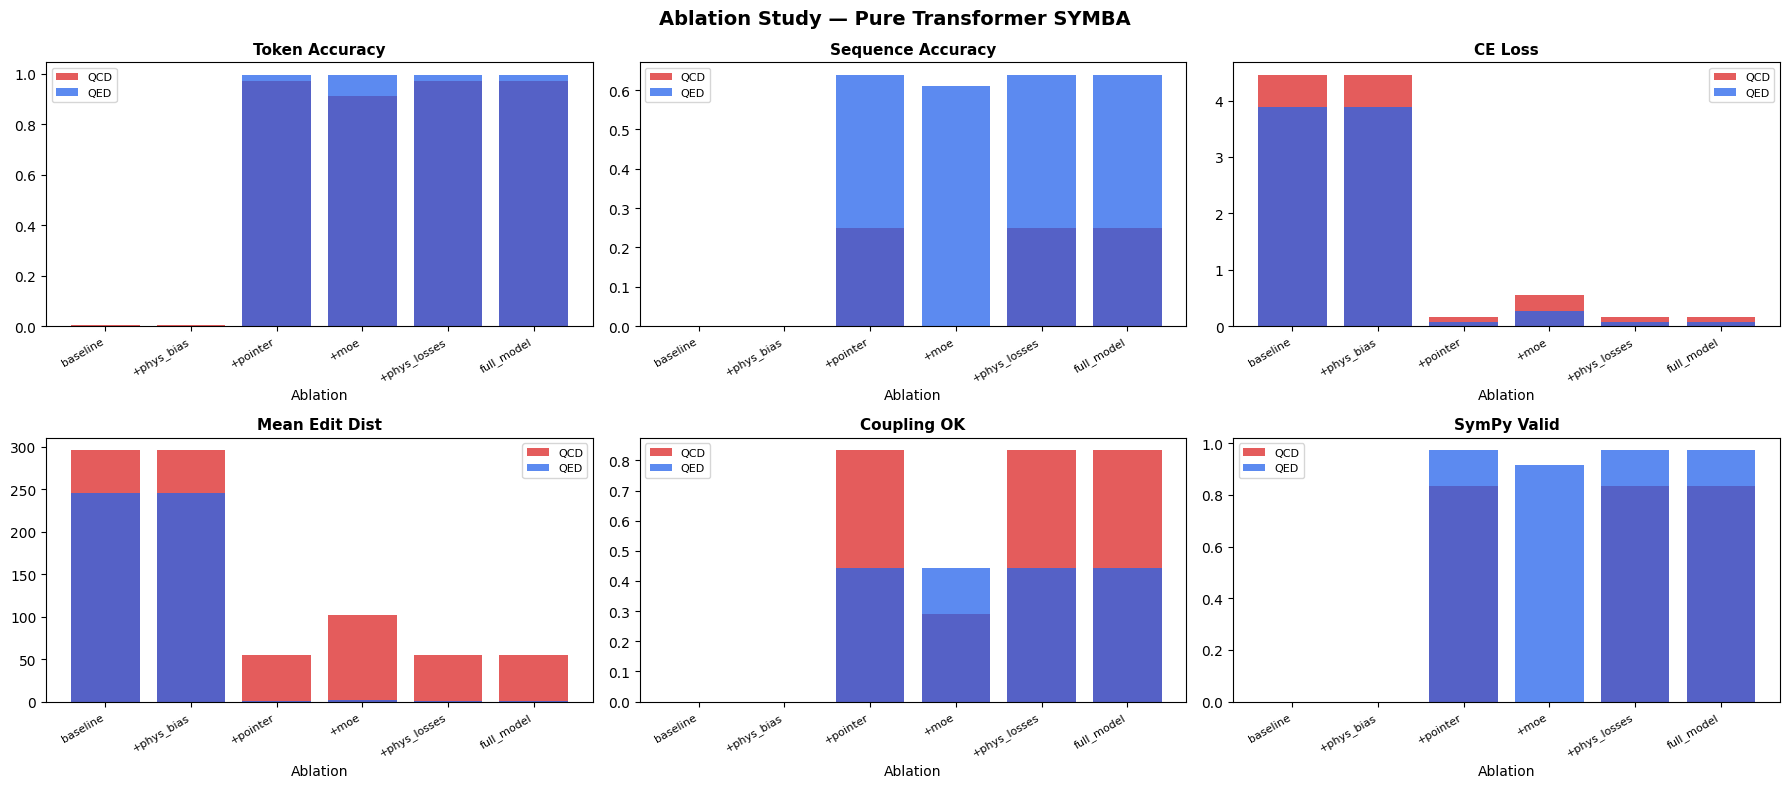

Saved ablation_bars.png


In [40]:
if not results_df.empty:
    abl_names  = [k for k,_ in ABLATION_CONFIGS]
    colors     = {'QED': '#2563EB', 'QCD': '#DC2626'}
    plot_metrics = [
        ('tok_acc',     'Token Accuracy',    True),
        ('seq_acc',     'Sequence Accuracy', True),
        ('ce_loss',     'CE Loss',           False),
        ('mean_ed',     'Mean Edit Dist',    False),
        ('coupling_ok', 'Coupling OK',       True),
        ('sympy_valid', 'SymPy Valid',       True),
    ]
    n = len(plot_metrics)
    fig, axes = plt.subplots(2, 3, figsize=(18, 8))
    axes = axes.flatten()
    for ax, (col, title, higher_better) in zip(axes, plot_metrics):
        sub = results_df[results_df['ablation'].isin(abl_names)]
        for label, grp in sub.groupby('label'):
            vals = []
            for abl in abl_names:
                row = grp[grp['ablation'] == abl]
                vals.append(row[col].values[0] if not row.empty and col in row.columns else 0)
            ax.bar(range(len(abl_names)), vals, label=label, alpha=0.75, color=colors.get(label,'gray'))
        ax.set_title(title, fontsize=11, fontweight='bold')
        ax.set_xticks(range(len(abl_names)))
        ax.set_xticklabels(abl_names, rotation=30, ha='right', fontsize=8)
        ax.legend(fontsize=8)
        ax.set_xlabel('Ablation')
    fig.suptitle('Ablation Study — Pure Transformer SYMBA', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['eval_dir'], 'ablation_bars.png'), dpi=150, bbox_inches='tight')
    plt.show()
    print('Saved ablation_bars.png')


## Cell 25 — Training Curves

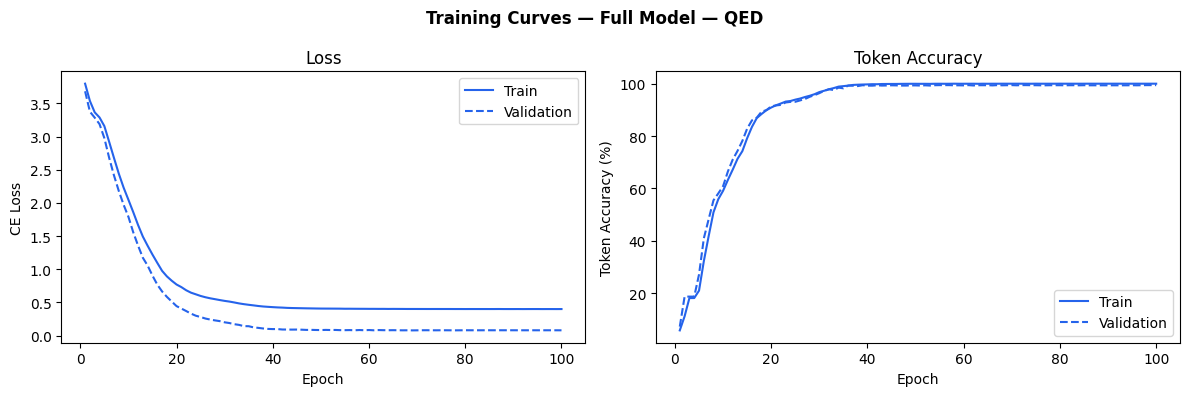

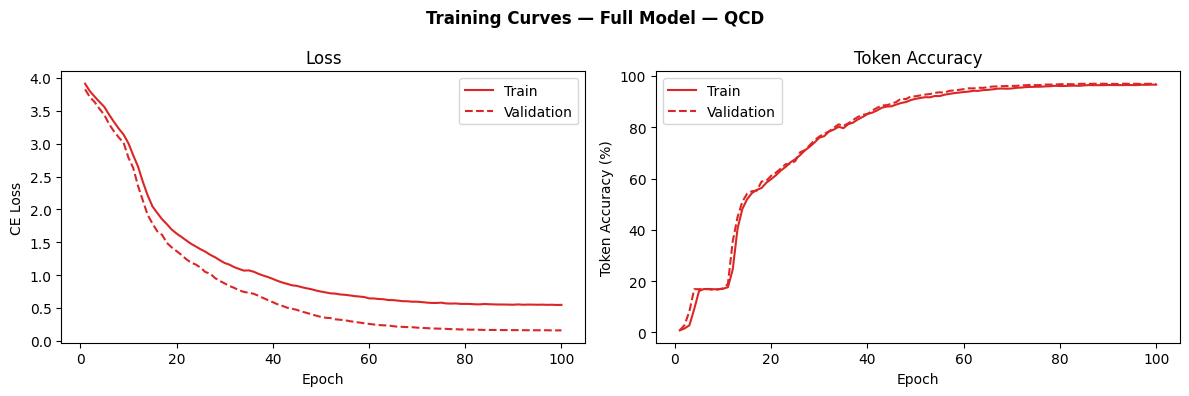

In [41]:
for label in LABELS:
    hist = ALL_HISTORIES.get(f'full_model_{label}')
    if not hist: continue
    epochs = range(1, len(hist['tr_loss'])+1)
    color  = '#2563EB' if label == 'QED' else '#DC2626'
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f'Training Curves — Full Model — {label}', fontsize=12, fontweight='bold')
    axes[0].plot(epochs, hist['tr_loss'],    label='Train',      color=color)
    axes[0].plot(epochs, hist['val_loss'],   label='Validation', color=color, linestyle='--')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('CE Loss'); axes[0].legend()
    axes[0].set_title('Loss')
    axes[1].plot(epochs, [v*100 for v in hist['tr_tok_acc']],  label='Train',      color=color)
    axes[1].plot(epochs, [v*100 for v in hist['val_tok_acc']], label='Validation', color=color, linestyle='--')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Token Accuracy (%)'); axes[1].legend()
    axes[1].set_title('Token Accuracy')
    plt.tight_layout()
    plt.savefig(os.path.join(CFG['eval_dir'], f'training_curves_{label}.png'), dpi=150, bbox_inches='tight')
    plt.show()


## Cell 26 — Qualitative Examples: Predictions vs Ground Truth

In [42]:
def show_examples(label: str, n: int = 5):
    ds        = DATASETS[label]
    tgt_vocab = ds['tgt_vocab']
    ckpt_path = os.path.join(CFG['ckpt_dir'], 'full_model', f'{label}_best.pth')
    if not os.path.exists(ckpt_path):
        print(f'  [MISSING] {ckpt_path}'); return

    pkg = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)
    model, _ = build_model(label, pkg['cfg'])
    model.load_state_dict(pkg['model'], strict=False)
    model.eval()

    grammar_mask = make_grammar_mask(tgt_vocab)
    loader = DataLoader(ds['test'], batch_size=1, shuffle=True, collate_fn=collate_fn)

    for i, (enc_a, enc_b, tgt, meta) in enumerate(loader):
        if i >= n: break
        enc_a = enc_a.to(DEVICE); enc_b = enc_b.to(DEVICE)
        pred_ids  = greedy_decode(model, enc_a, enc_b, tgt_vocab,
                                  grammar_mask=grammar_mask)
        pred_toks = [tgt_vocab[t] for t in pred_ids]
        gt_toks   = meta['sq_tokens'][0]
        sv        = sympy_full_validate(pred_toks)
        _, _, coup_ok = check_coupling_power(pred_toks, meta['n_vertices'][0],
                                             meta['is_qcd'][0], tgt_vocab)
        print(f'\n─── Example {i+1} ───────────────────────────────')
        print(f'  GT:   {" ".join(gt_toks[:60])}')
        print(f'  PRED: {" ".join(pred_toks[:60])}')
        print(f'  SymPy valid={sv["sympy_valid"]}  dim_ok={sv["dim_ok"]}  coupling_ok={coup_ok}')
        ed = editdistance.eval(pred_ids, [tgt_vocab[t] for t in gt_toks])
        print(f'  Edit distance: {ed}  |  Exact: {pred_toks == gt_toks}')

for label in LABELS:
    if label in DATASETS:
        show_examples(label, n=3)



─── Example 1 ───────────────────────────────
  GT:   2 * e ^ 4 * MOMENTUM_14 * MOMENTUM_34 * ( MOMENTUM_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) + ( - 4 ) * i * e ^ 2 * ( i * e ^ 2 * m_mu ^ 2 * ( m_mu ^ 2 + - 1 / 2 * MOMENTUM_13 )
  PRED: 2 * e ^ 4 * MOMENTUM_14 * MOMENTUM_34 * ( MOMENTUM_23 + ( - 1 / 2 * reg_prop ) ^ ( - 2 ) + ( - 4 ) * i * e ^ 2 * ( i * e ^ 2 * m_mu ^ 2 * ( m_mu ^ 2 + 1 / 2 * MOMENTUM_12 )
  SymPy valid=True  dim_ok=False  coupling_ok=False
  Edit distance: 17  |  Exact: False

─── Example 2 ───────────────────────────────
  GT:   2 * e ^ 4 * MOMENTUM_23 * MOMENTUM_24 * ( MOMENTUM_23 + - 1 / 2 * reg_prop ) ^ ( - 2 ) + - 1 / 4 * i * e ^ 2 * ( i * e ^ 2 * m_mu ^ 2 * ( 16 * MOMENTUM_23 + 8 * MOMENTUM_24 ) / ( MOMENTUM_23
  PRED: 2 * e ^ 4 * MOMENTUM_23 * MOMENTUM_24 * ( MOMENTUM_23 + 324 * ( - 1 / 2 * reg_prop ) ^ ( - 2 ) * ( - 2 ) ^ 2 * m_mu ^ 2 * ( m_mu ^ 2 * m_mu ^ 2 + ( - 1 / 2 * MOMENTUM_13 + 8 ) *
  SymPy valid=True  dim_ok=False  coupling_ok=False
  Edit distance: 4

## Cell 27 — Save Results Package

In [43]:
pkg = {
    'results_df'       : results_df.to_dict('records') if not results_df.empty else [],
    'all_histories'    : {k:v for k,v in ALL_HISTORIES.items() if v},
    'all_ckpts'        : ALL_CKPTS,
    'ablation_configs' : ABLATION_CONFIGS,
    'cfg'              : CFG,
    'labels'           : LABELS,
}
out = os.path.join(CFG['eval_dir'], 'full_results_package.pkl')
with open(out, 'wb') as f:
    pickle.dump(pkg, f)
print(f'Results saved to: {out}')

# Print final summary
if not results_df.empty:
    print('\n=== Final Summary ===')
    for label in LABELS:
        sub = results_df[results_df['label']==label]
        if sub.empty: continue
        best = sub.loc[sub['tok_acc'].idxmax()]
        print(f'{label}: best ablation={best["ablation"]}  '
              f'tok_acc={best["tok_acc"]*100:.2f}%  seq_acc={best["seq_acc"]*100:.2f}%  '
              f'sympy_valid={best["sympy_valid"]*100:.1f}%')


Results saved to: /content/results/pure_transformer/full_results_package.pkl

=== Final Summary ===
QED: best ablation=+pointer  tok_acc=99.49%  seq_acc=63.89%  sympy_valid=97.2%
QCD: best ablation=+pointer  tok_acc=97.05%  seq_acc=25.00%  sympy_valid=83.3%


In [44]:
import shutil
from google.colab import files

shutil.make_archive('my_folder', 'zip', '/content/results')
files.download('my_folder.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>